In [ ]:
from torch.utils.data import DataLoader
from src.dataloader import TrashCanDataset
import torch
from src.model import ObjDetector,save_detector,load_detector,ObjDetectorRPN
# from src.model2 import ObjDetectorRPN
import os
import torch.nn as nn
import gc

In [ ]:
DATASET_PATH = os.path.join("dataset", "material_version")
IMAGE_SIZE = (480,270)
train_set = TrashCanDataset(
    image_root=os.path.join(DATASET_PATH, "train"),
    ann_path=os.path.join(DATASET_PATH, "instances_train_trashcan.json"),
    img_size=IMAGE_SIZE
)
classes= ['background'] + train_set.categories
print(classes)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = 'cpu'

val_set = TrashCanDataset(
    image_root=os.path.join(DATASET_PATH, "val"),
    ann_path=os.path.join(DATASET_PATH, "instances_val_trashcan.json"),
    img_size=IMAGE_SIZE
)

val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

detector = ObjDetectorRPN(classes=classes,window_step_size=32,window_size=[64,128],min_size=(64,64),image_size=IMAGE_SIZE,device=device,lr=1e-4,iou_thresh=0.5,n_clusters=64,use_sliding_window=False)
# detector.build_vocabulary_from_dataset(train_loader)
# detector = ObjDetectorRPN(classes=classes,device=device,iou_thresh=0.5,window_sizes=[16,64,96],window_step_size=32,lr=1e-4)
# detector = ObjDetector(classes=classes,device=device,iou_thresh=0.5,window_sizes=[64,128],window_step_size=32)
# Step 1: build BoVW vocabulary
# detector.build_vocabulary_from_dataset(train_loader, max_patches=5000)
history = detector.train(train_loader,val_loader,val_set,epochs=100,vis_every=2,checkpoint_every=20,checkpoint_dir='./checkpoints2')

['rov', 'plant', 'animal_fish', 'animal_starfish', 'animal_shells', 'animal_crab', 'animal_eel', 'animal_etc', 'trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']


In [ ]:
save_detector(detector,'./model2.pt')

Saved ObjDetectorRPN to ./model.pt


: 

In [ ]:
import matplotlib.pyplot as plt

: 

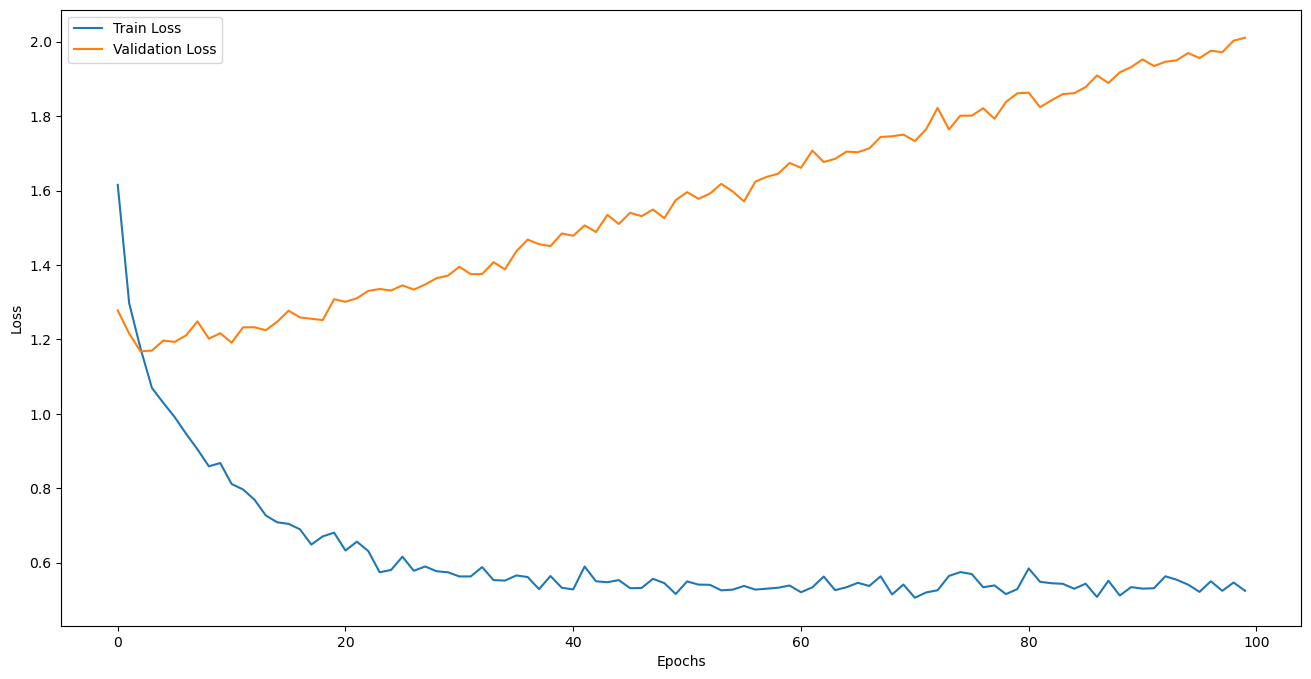

: 

: 

In [ ]:
train_loss = history[0]
val_loss = history[1]

plt.figure(figsize=(16,8))
plt.plot(train_loss,label='Train Loss')
plt.plot(val_loss,label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()